In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [ ]:
# --- 1. 기본 설정 및 DB 연결 ---
print("--- [Step 1] DB 연결 및 설정 ---")
from google.colab import drive
drive.mount('/content/drive')

# [!] 본인의 DB 경로로 수정 필수
db_path = '/content/drive/MyDrive/MIMIC4-hosp-icu.db'

# 로컬 임시 DB 생성
conn = sqlite3.connect('local_analysis.db')
print("  - 로컬 DB 연결 성공.")

# 원본 DB ATTACH
try:
    conn.execute(f"ATTACH DATABASE '{db_path}' AS remote_db")
    print("  - 원본 DB (remote_db) ATTACH 성공.")
except Exception as e:
    print(f"[오류] DB 연결 실패: {e}")
    raise

--- [Step 1] DB 연결 및 설정 ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  - 로컬 DB 연결 성공.
  - 원본 DB (remote_db) ATTACH 성공.


In [ ]:
# --- [Step 2] 코호트 확장 (2014-2022) - 엄격한 기준 적용 ---
print("\n--- [Step 2] 코호트 확장 (2014-2022) ---")

# 1. SQL로 데이터 로드 (기준 4, 6, 3)
# - 기준 4: 2014-2022년도 필터링
# - 기준 6: subject_id, hadm_id, stay_id 조인
# - 기준 3: intime, outtime 누락 제거
cohort_sql = """
SELECT
    ie.subject_id,
    ie.hadm_id,
    ie.stay_id,
    ie.intime,
    ie.outtime,
    adm.admission_type,
    p.anchor_year_group
FROM remote_db.icustays ie
JOIN remote_db.patients p ON ie.subject_id = p.subject_id
JOIN remote_db.admissions adm ON ie.hadm_id = adm.hadm_id
WHERE
    p.anchor_year_group IN ('2014 - 2016', '2017 - 2019', '2020 - 2022') -- (기준 4)
    AND adm.admission_type != 'ELECTIVE' -- (제안서 기준)
    AND ie.intime IS NOT NULL   -- (기준 3)
    AND ie.outtime IS NOT NULL  -- (기준 3)
"""

print(" 코호트 로드 중...")
extended_cohort = pd.read_sql_query(cohort_sql, conn)
extended_cohort['intime'] = pd.to_datetime(extended_cohort['intime'])
extended_cohort['outtime'] = pd.to_datetime(extended_cohort['outtime'])

# 2. 환자별 첫 번째 입실만 선택 (기준 2)
# - subject_id별로 intime 순 정렬 후 첫 번째만 남김
print("  - 환자별 첫 번째 입실 필터링 중...")
extended_cohort = extended_cohort.sort_values(by=['subject_id', 'intime'])
extended_cohort = extended_cohort.drop_duplicates(subset=['subject_id'], keep='first')

# 3. LOS 계산 (기준 5)
# - outtime - intime (일 단위)
extended_cohort['los_days'] = (extended_cohort['outtime'] - extended_cohort['intime']).dt.total_seconds() / (24 * 60 * 60)
extended_cohort = extended_cohort[extended_cohort['los_days'] > 0] # 음수 제거

# 4. 로컬 DB에 업로드
extended_cohort.to_sql('temp_cohort_ext', conn, if_exists='replace', index=False, dtype={'intime': 'DATETIME'})

print(f"  - 확장 코호트: N={len(extended_cohort)}")
print(f"  - 연도별 분포:\n{extended_cohort['anchor_year_group'].value_counts().sort_index()}")


--- [Step 2] 코호트 확장 (2014-2022) ---
  - 확장된 코호트 로드 중...
  - 환자별 첫 번째 입실 필터링 중...
  - [완료] 엄격한 기준이 적용된 확장 코호트: N=33045
  - 연도별 분포:
anchor_year_group
2014 - 2016    12776
2017 - 2019    11853
2020 - 2022     8416
Name: count, dtype: int64



--- [Step 3] 2014-2016 약물 데이터(Inputevents) 점검 ---

[연도별 약물 데이터 커버리지 결과]
  anchor_year_group  total_patients  patients_with_drug  coverage_ratio
0       2014 - 2016           12776               12363        0.967674
1       2017 - 2019           11853               11360        0.958407
2       2020 - 2022            8416                3607        0.428588


/tmp/ipython-input-2258654082.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=drug_stats, x='anchor_year_group', y='coverage_ratio', palette='viridis')


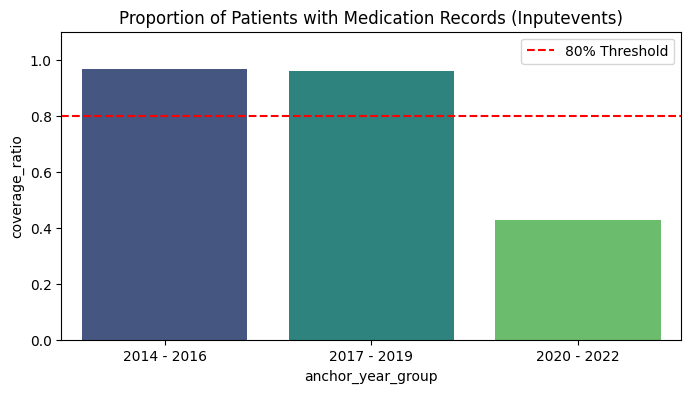

>> 해석: 2014-2016의 비율이 다른 연도와 비슷하면 '사용 가능', 현저히 낮으면(0에 가까우면) '사용 불가'입니다.


In [ ]:
# --- 3. 2014-2016 약물 데이터 누락 확인 ---
print("\n--- [Step 3] 2014-2016 약물 데이터(Inputevents) 점검 ---")

drug_check_sql = """
SELECT
    t.anchor_year_group,
    COUNT(DISTINCT t.stay_id) as total_patients,
    COUNT(DISTINCT i.stay_id) as patients_with_drug
FROM
    temp_cohort_ext AS t
LEFT JOIN
    remote_db.inputevents AS i
    ON t.stay_id = i.stay_id
    AND i.starttime BETWEEN t.intime AND DATETIME(t.intime, '+48 hours')
GROUP BY
    t.anchor_year_group
"""

drug_stats = pd.read_sql_query(drug_check_sql, conn)
drug_stats['coverage_ratio'] = drug_stats['patients_with_drug'] / drug_stats['total_patients']

print("\n[연도별 약물 데이터 커버리지 결과]")
print(drug_stats)

plt.figure(figsize=(8, 4))
sns.barplot(data=drug_stats, x='anchor_year_group', y='coverage_ratio', palette='viridis')
plt.title("Proportion of Patients with Medication Records (Inputevents)")
plt.ylim(0, 1.1)
plt.axhline(0.8, color='r', linestyle='--', label='80% Threshold')
plt.legend()
plt.show()

In [ ]:
# --- 4. 시간축 정보 손실 확인 (Binning Analysis) ---
print("\n--- [Step 4] 시간축 정보 손실 확인 (Binning Analysis) ---")

# 분석 함수
def analyze_bin_sparsity(raw_data_sql, item_name, bin_sizes=[4, 8, 12, 24]):
    print(f"\n[{item_name}] 데이터 로드 및 분석 중...")
    df_raw = pd.read_sql_query(raw_data_sql, conn)
    df_raw['charttime'] = pd.to_datetime(df_raw['charttime'])
    df_raw['intime'] = pd.to_datetime(df_raw['intime'])

    # 경과 시간 계산
    df_raw['hours_since'] = (df_raw['charttime'] - df_raw['intime']).dt.total_seconds() / 3600
    df_raw = df_raw[(df_raw['hours_since'] >= 0) & (df_raw['hours_since'] <= 48)]

    total_patients = df_raw['stay_id'].nunique() # 실제 데이터가 있는 환자 수 기준 (또는 코호트 전체 기준)

    for bin_h in bin_sizes:
        # Bin 인덱스 할당
        df_raw['bin_idx'] = (df_raw['hours_since'] // bin_h).astype(int)
        max_bin = int(48 / bin_h)

        # (Bin, Item)별 데이터 존재 비율
        presence = df_raw.groupby(['itemid', 'bin_idx'])['stay_id'].nunique().reset_index()
        presence['ratio'] = presence['stay_id'] / total_patients

        pivot_table = presence.pivot(index='itemid', columns='bin_idx', values='ratio')
        pivot_table = pivot_table.reindex(columns=range(max_bin)).fillna(0)

        # 시각화
        plt.figure(figsize=(12, len(pivot_table)*0.6 + 1))
        sns.heatmap(pivot_table, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0, vmax=1)
        plt.title(f"{item_name} - Data Presence Ratio (Bin Size: {bin_h} hours)\n(Red: High Loss, Green: Low Loss)")
        plt.xlabel(f"Time Bin (Every {bin_h}h)")
        plt.show()


--- [Step 4] 시간축 정보 손실 확인 (Binning Analysis) ---



[Vital Signs (HR, RR, MAP, SpO2, Temp)] 데이터 로드 및 분석 중...


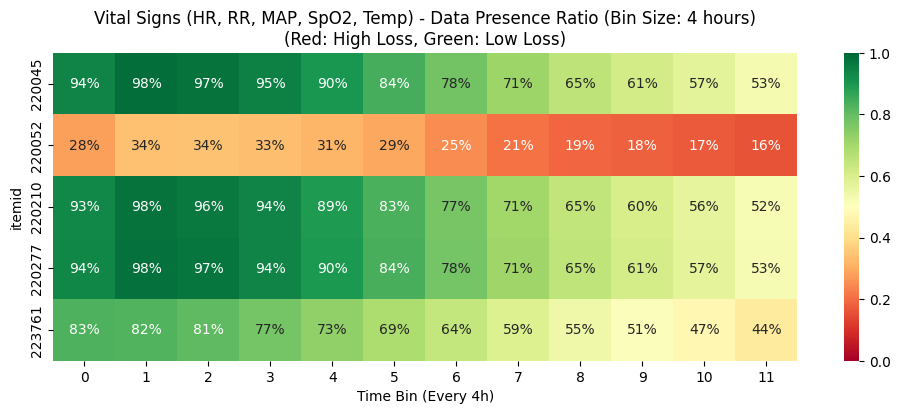

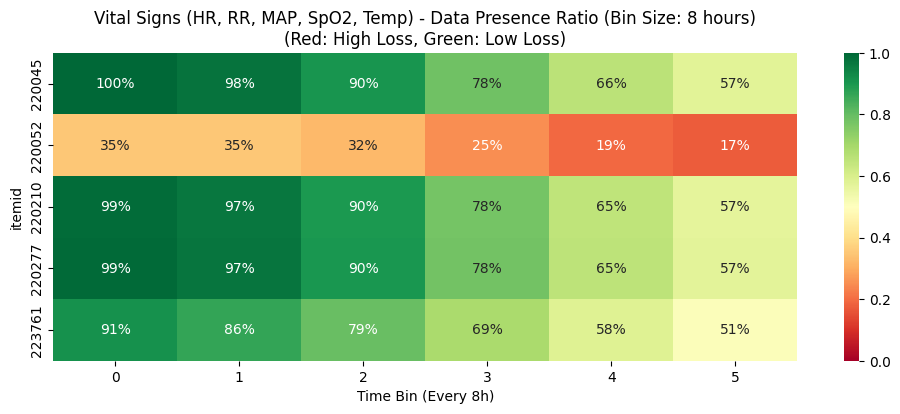

In [ ]:
# 4-1. Vital Sign 분석
# (주요 Vital 5개만 샘플로 확인)
vital_ids = (220045, 220210, 220052, 220277, 223761)
vital_sql = f"""
SELECT c.stay_id, c.itemid, c.charttime, t.intime
FROM remote_db.chartevents c
JOIN temp_cohort_ext t ON c.stay_id = t.stay_id
WHERE c.itemid IN {vital_ids}
AND c.charttime BETWEEN t.intime AND DATETIME(t.intime, '+48 hours')
"""
analyze_bin_sparsity(vital_sql, "Vital Signs (HR, RR, MAP, SpO2, Temp)", bin_sizes=[4, 8])


[Lab Tests (Cr, WBC, PLT, Lac, K)] 데이터 로드 및 분석 중...


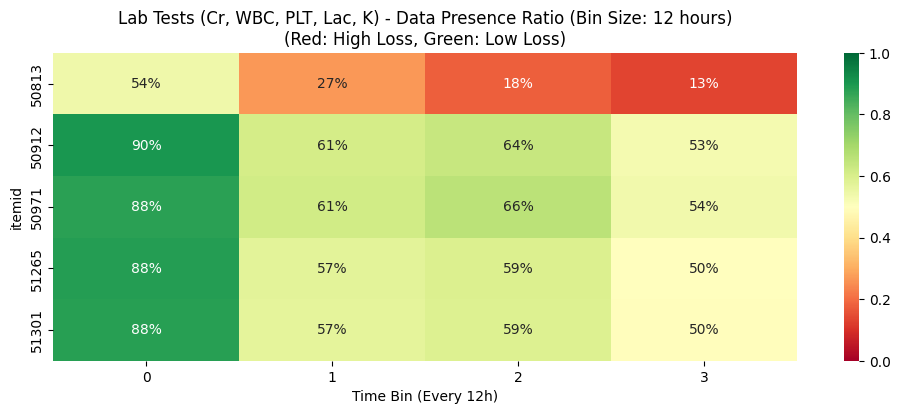

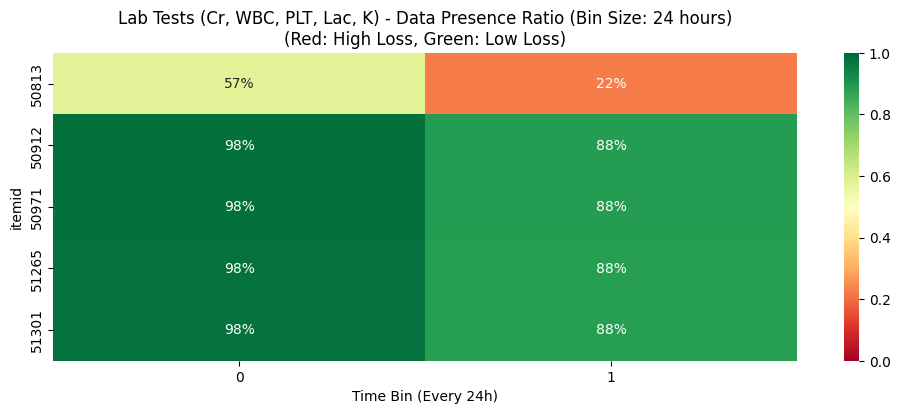


--- 모든 분석 완료 ---


In [ ]:
# 4-2. Lab Test 분석
# (주요 Lab 5개만 샘플로 확인)
lab_ids = (50912, 51301, 51265, 50813, 50971) # Cr, WBC, PLT, Lac, K
lab_sql = f"""
SELECT t.stay_id, c.itemid, c.charttime, t.intime
FROM remote_db.labevents c
JOIN temp_cohort_ext t ON c.subject_id = t.subject_id -- Lab은 subject_id 조인
WHERE c.itemid IN {lab_ids}
AND c.charttime BETWEEN t.intime AND DATETIME(t.intime, '+48 hours')
"""
analyze_bin_sparsity(lab_sql, "Lab Tests (Cr, WBC, PLT, Lac, K)", bin_sizes=[12, 24])

conn.close()
print("\n--- 모든 분석 완료 ---")